In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('../data/sales_df.csv',index_col=0)

In [60]:
df.head()

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [61]:
df.shape

(805549, 9)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   805549 non-null  int64  
 1   Invoice      805549 non-null  int64  
 2   StockCode    805549 non-null  str    
 3   Description  805549 non-null  str    
 4   Quantity     805549 non-null  int64  
 5   InvoiceDate  805549 non-null  str    
 6   Price        805549 non-null  float64
 7   Customer ID  805549 non-null  float64
 8   Country      805549 non-null  str    
dtypes: float64(2), int64(3), str(4)
memory usage: 55.3 MB


In [63]:
df.describe()

,Unnamed: 0,Invoice,Quantity,Price,Customer ID
count,805549.000000,805549.000000,805549.000000,805549.000000,805549.000000
mean,271948.040591,537410.713358,13.290522,3.206561,15331.954970
std,150562.092204,26666.068909,143.634088,29.199173,1696.737039
min,0.000000,489434.000000,1.000000,0.001000,12346.000000
25%,143764.000000,514962.000000,2.000000,1.250000,13982.000000
50%,275941.000000,536989.000000,5.000000,1.950000,15271.000000
75%,401176.000000,561617.000000,12.000000,3.750000,16805.000000
max,541909.000000,581587.000000,80995.000000,10953.500000,18287.000000


In [64]:
df.isnull().sum()

Unnamed: 0     0
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

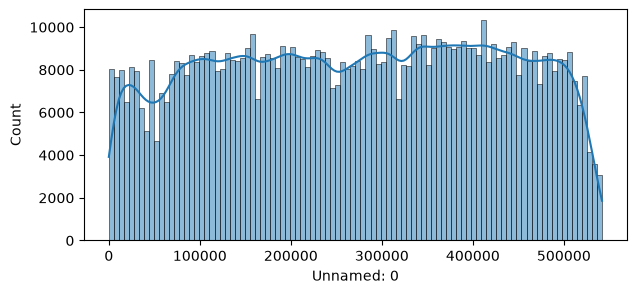

Unnamed: 0


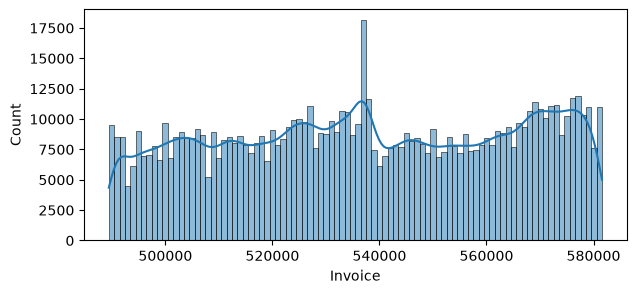

Invoice


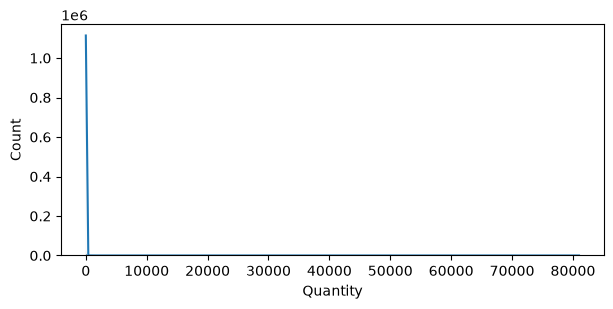

Quantity


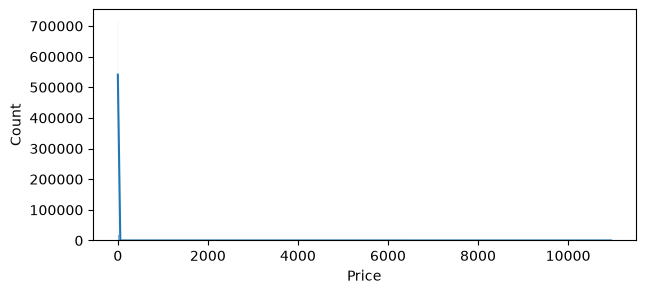

Price


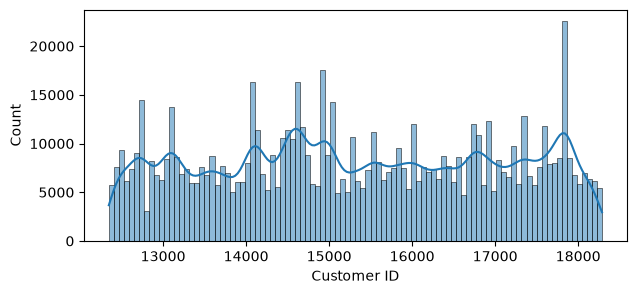

Customer ID


In [65]:
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(7,3))
    sns.histplot(df[col],kde=True)
    plt.show()
    print(col)

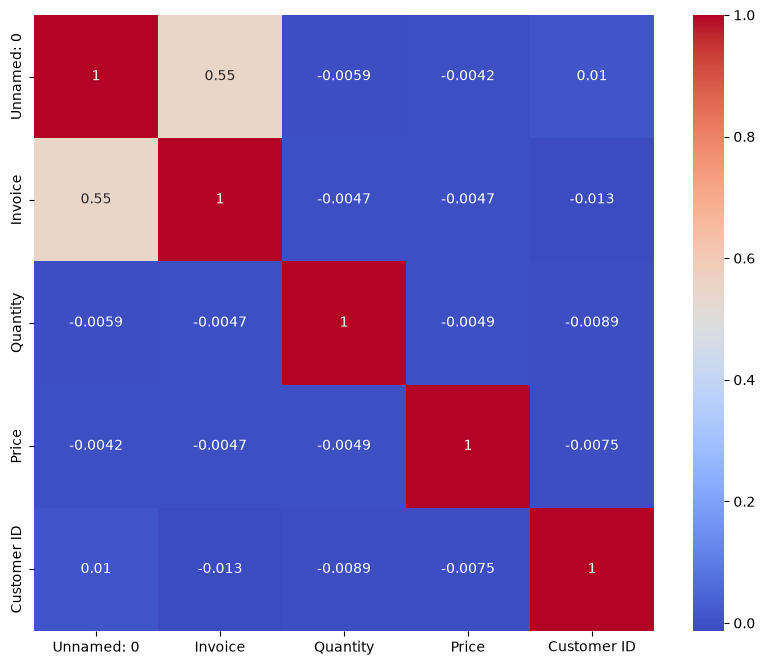

In [66]:
num_df=df.select_dtypes(include='number')
corr=num_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()


# Feature enginnering

In [68]:
# extract the month and year from the date columns
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Year']=df['InvoiceDate'].dt.year
df['Month']=df['InvoiceDate'].dt.month
df['Days']=df['InvoiceDate'].dt.day

In [69]:
df.head(3)

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,Days
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1


# Save data for the power BI report

In [70]:
df.to_csv('../data/report_data.csv',index=False)

# Preprocessing for the MAchine learning models

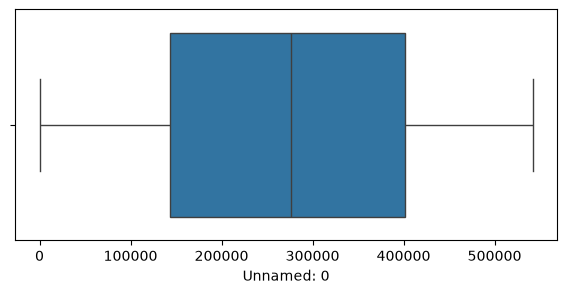

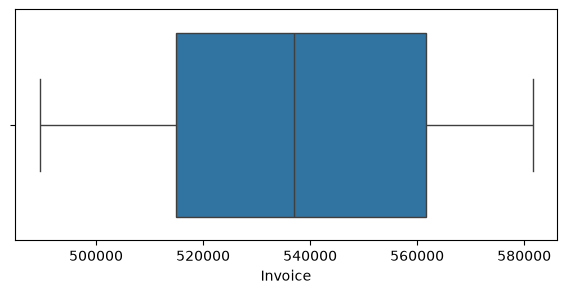

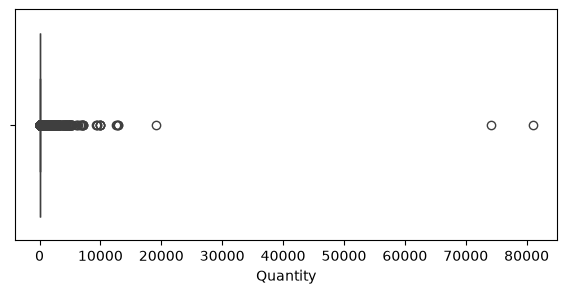

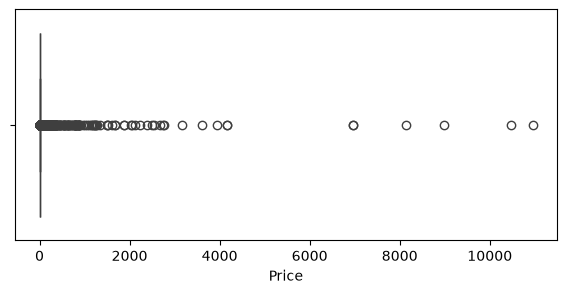

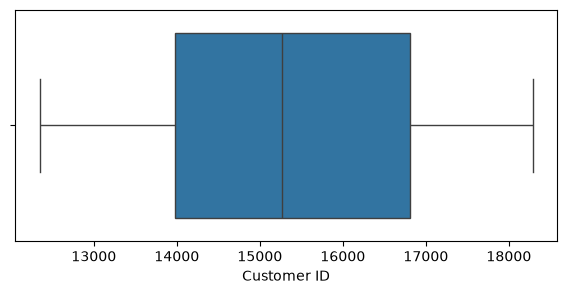

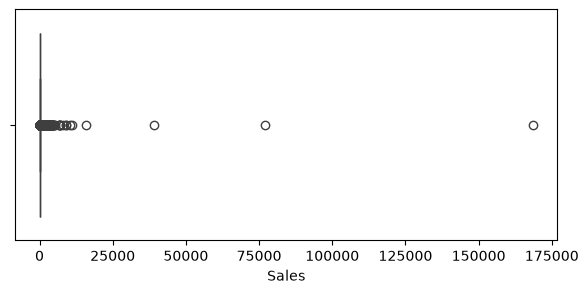

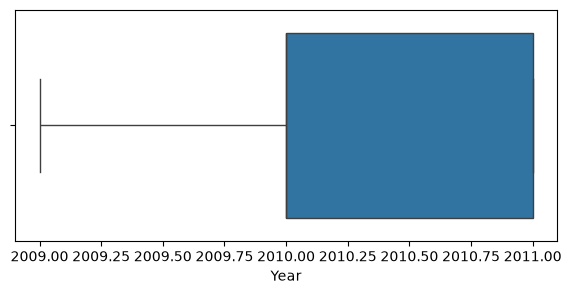

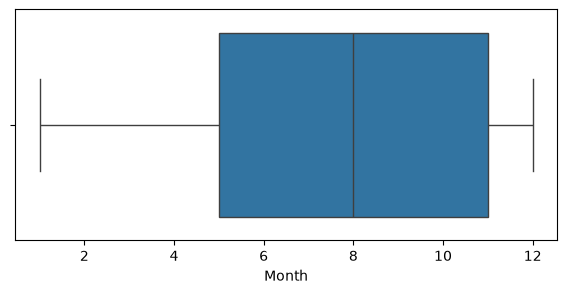

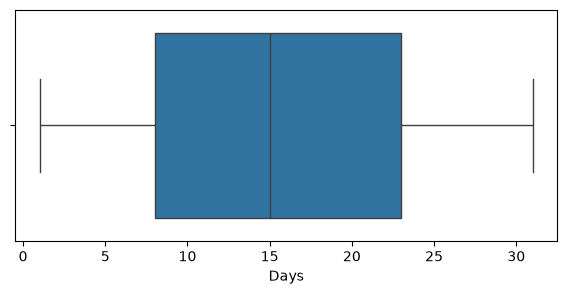

In [71]:
for col in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.show()
    

In [72]:
num_cols=['Price','Quantity','Sales']
def outlier_detection(df,col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    higher_limit=Q3+1.5*IQR
    return lower_limit,higher_limit



In [73]:
for col in num_cols:
    low, high = outlier_detection(df, col)
    n = ((df[col] < low) | (df[col] > high)).sum()
    print(f"{col}: low={low:.2f}, high={high:.2f}, outliers={n} ({n/len(df)*100:.2f}%)")

Price: low=-2.50, high=7.50, outliers=67346 (8.36%)
Quantity: low=-13.00, high=27.00, outliers=51983 (6.45%)
Sales: low=-16.88, high=41.33, outliers=66382 (8.24%)


In [76]:
for col in ['Price','Quantity']:
    low,high=outlier_detection(df,col)
    df=df[(df[col]>=low)& df[col]<=high]
    df.shape

In [77]:
df['Sales']=df['Quantity']*df['Price']

In [78]:
df['Description'].unique()

<StringArray>
['15CM CHRISTMAS GLASS BALL 20 LIGHTS',                  'PINK CHERRY LIGHTS',
                ' WHITE CHERRY LIGHTS',        'RECORD FRAME 7" SINGLE SIZE ',
      'STRAWBERRY CERAMIC TRINKET BOX',          'PINK DOUGHNUT TRINKET POT ',
                 'SAVE THE PLANET MUG',  'FANCY FONT HOME SWEET HOME DOORMAT',
                           'CAT BOWL ',      'DOG BOWL , CHASING BALL DESIGN',
 ...
           'SNACK TRAY HAPPY FOREST  ',             'SNACK TRAY PAISLEY PARK',
      'SET OF 6 RIBBONS COUNTRY STYLE',        'SNACK TRAY RED VINTAGE DOILY',
 'SET OF 6 RIBBONS PERFECTLY PRETTY  ',       'GIN AND TONIC DIET METAL SIGN',
              'SET OF 6 RIBBONS PARTY',     'SILVER AND BLACK ORBIT NECKLACE',
  'CREAM HANGING HEART T-LIGHT HOLDER',         'PAPER CRAFT , LITTLE BIRDIE']
Length: 5283, dtype: str

In [79]:
df.head(3)

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,Days
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1


In [81]:
# Drop the columns that are not needed for analysis
df.drop(columns=['InvoiceDate'],inplace=True)